# Benchmarking and Comparing Performance of ImageNet Pre-trained Popular Classification Models

This code evaluates and compares the performance of popular pre-trained image classification models (AlexNet, VGG19, GoogleNet, ResNet101, DenseNet121, MobileNet_v2) using a subset of ImageNet images.
The code performs the following steps:

1. Loads pre-trained models from the torchvision library.
2. Creates an ImageNet dataset and dataloader for the ImageNet sample images.
3. Evaluates each model by calculating its inference time, model size, and FLOPs.
4. Computes and reports the top-1 and top-5 accuracy of each model on the ImageNet samples.
5. Generates bar plots to visualize the performance comparison of the models across different metrics (inference time, model size, FLOPs, and accuracies).

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim
import time
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import random

In [6]:
%pip install torchprofile
from torchprofile import profile_macs

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Load the models (You can try loading other models also, but ensure its compatible with input size of 224x224 and also pre-trained on ImageNet)
from torchvision import models
from torchvision.models import alexnet, vgg19, googlenet, resnet101, densenet121, mobilenet_v2

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

We will be using the sample ImageNet dataset available in the [link](https://github.com/EliSchwartz/imagenet-sample-images)

A subset of 100 images is shared at the [link](https://drive.google.com/file/d/1ws6fnkXjbEINK-id-IuU4vZlTKiUDYDg/view?usp=sharing)

Download to your Gdrive and update the path below

In [11]:
# Path to your compressed file in Google Drive
zip_path = 'ImageNetSamples.zip' # Make sure the path to your drive folder is updated!
ROOT = '/content'
datasets.utils.extract_archive(zip_path, ROOT) # Observe if the folder with name ImageNetSamples is created on the left pane <--

'\\content'

Define an ImageNetDataset class provides a way to load and access images from a folder, extract their labels, and apply transformations. This is as per the ImageNet datastyle

In [12]:
class ImageNetDataset(Dataset):
    def __init__(self, image_folder, class_list, transform=None):
        """
        Args:
            image_folder (str): Path to the folder containing images.
            class_list_file (str): Path to the file containing ImageNet class list.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.image_folder = image_folder
        self.transform = transform

        # Load ImageNet class list from file
        self.class_list = class_list

        # List all images in the folder
        self.image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_folder, img_name)

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Extract class label from the image filename
        # Assuming the class name is represented as part of the filename, e.g., "n01440764_sea_urchin.JPEG"
        class_name = '_'.join(img_name.split('_')[1:]).split('.')[0]  # Extracting "sea_urchin" from "n01440764_sea_urchin.JPEG"
        label = self.class_list.index(class_name) if class_name in self.class_list else -1

        if self.transform:
            image = self.transform(image)

        return image, label

Create transform as per the ImageNet dataset

In [13]:
transform = transforms.Compose([
 transforms.Resize(256),
 transforms.CenterCrop(224),
 transforms.ToTensor(),
 transforms.Normalize(
 mean=[0.485, 0.456, 0.406],
 std=[0.229, 0.224, 0.225]
 )])

The ImageNet classes (1000 class) is defined in the text file. Please download the same from the [link](https://drive.google.com/file/d/1TfR3LfjbDYC8TN-KO1Tg34TtiFSUT4EL/view?usp=sharing) and upload to your Gdrive and update the path below.

In [16]:
with open('imagenet_classes.txt') as f: #Update the path as per the location of the text file
  classes = [line.strip().split(', ')[1] for line in f.readlines()]

Instantiate the dataset and dataloader


In [17]:
dataset = ImageNetDataset(image_folder='/content/ImageNetSamples',class_list = classes, transform=transform)

# Dynamically set batch size based on available CPU cores and memory
import psutil
import os

# Get number of CPU cores and available memory
num_cores = os.cpu_count()
available_memory = psutil.virtual_memory().available / (1024 * 1024 * 1024)  # Convert to GB

# Base batch size on available resources, with some safety margins
BATCH_SIZE = max(1, min(
    int(num_cores / 2),  # Use half of available CPU cores
    int(available_memory / 2)  # Or half of available memory in GB
))
print("Batch size: ", BATCH_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

Batch size:  1


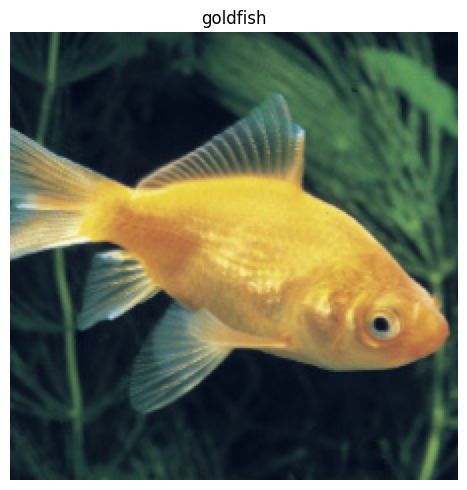

In [18]:
# Display some sample images with class names
N = 5

# Get one batch from the test_iterator
data_iter = iter(dataloader)
images, labels = next(data_iter)  # Fetch one batch using next()

# Randomly select N samples from the batch
N = min(N, BATCH_SIZE)  # Adjust N to be within the bounds of the batch size

# Check if the batch size is greater than 1
if BATCH_SIZE > 1:
    # Randomly select N samples from the batch
    random_indices = random.sample(range(BATCH_SIZE), N)
    random_images = images[random_indices]
    random_labels = labels[random_indices]
    fig, axes = plt.subplots(1, N, figsize=(15, 5))  # Multiple subplots for batch size > 1
    for i in range(N):
        img = random_images[i].cpu()  # Move image to CPU if it's on GPU
        img = (img - img.min()) / (img.max() - img.min())  # Normalize the image to [0, 1]
        axes[i].imshow(img.numpy())  # Convert tensor to numpy for display
        axes[i].set_title(f"{classes[random_labels[i].item()]}")  # Display label
        axes[i].axis('off')  # Hide axes for cleaner visualization
else:
    # Since the batch size is 1, you can only access the first sample
    random_images = images[0:1]  # This will give you the only image in the batch
    random_labels = labels[0:1]  # Similarly for labels
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))  # Single subplot for batch size = 1
    img = random_images[0].cpu()  # Move image to CPU if it's on GPU
    img = (img - img.min()) / (img.max() - img.min())  # Normalize the image to [0, 1]
    img = img.permute(1, 2, 0)  # Change the shape from (C, H, W) to (H, W, C)
    axes.imshow(img.numpy())  # Convert tensor to numpy for display
    axes.set_title(f"{classes[random_labels[0].item()]}")  # Display label
    axes.axis('off')  # Hide axes for cleaner visualization



plt.tight_layout()
plt.show()

The below function assesses how often the correct label is within the top k predictions made by the model, providing a measure of its performance. Historically, for the ImageNet challenge the models are evaluated for top 1% and 5% accuracy.

Top-k Accuracy = (Number of Correct Top-k Predictions) / (Total Number of Predictions)

Where:

Number of Correct Top-k Predictions: This is the count of instances where the true label is among the top k predictions made by the model for a given sample.
Total Number of Predictions: This is simply the total number of samples being evaluated.

In [19]:
def calculate_topk_accuracy(y_pred, y_act, k = 5):
    with torch.no_grad():
        batch_size = y_act.shape[0]
        _, top_pred = y_pred.topk(k, 1)
        top_pred = top_pred.t()
        correct = top_pred.eq(y_act.view(1, -1).expand_as(top_pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim = True)
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim = True)
        acc_1 = correct_1 / batch_size
        acc_k = correct_k / batch_size
    return acc_1, acc_k

Function provides a way to quantify how fast, large, computationally complex, and accurate a given machine learning model is when applied to a specific dataset.

In [20]:
# Function to evaluate model inference time, size, and FLOPs
def evaluate_model(model, dataloader, criterion, device):

    # Move model to device (GPU or CPU)
    model.to(device)
    model.eval()

    correct = 0
    total = 0
    inference_time = []
    acc_1_accum = []
    acc_k_accum = []
    count = 0

    with torch.no_grad():
        for image, label in dataloader:
            image, label = image.to(device), label.to(device)
            # Inference Time
            start_time = time.time()
            output = model(image)
            end_time = time.time()
            inference_time.append((end_time - start_time)/image.shape[0])
            count += 1
            # Calculate accuracy
            #_, predicted = torch.max(output, 1)
            acc_1, acc_k = calculate_topk_accuracy(output, label, k = 5)
            acc_1_accum.append(acc_1)
            acc_k_accum.append(acc_k)

    inference_time = sum(inference_time) / count
    acc_1_accum = sum(acc_1_accum) / count
    acc_k_accum = sum(acc_k_accum) / count

    # Print results
    print(f"Inference Time: {inference_time:.4f} seconds")
    # Model Size
    torch.save(model.state_dict(), "temp.pth")
    model_size = os.path.getsize("temp.pth") / (1024 * 1024)  # Convert to MB
    os.remove("temp.pth")

    # FLOPs
    example_input = torch.randn(1, 3, 224, 224).to(device)
    flops = profile_macs(model, example_input)

    return inference_time, model_size, flops, acc_1_accum, acc_k_accum

This code section loads six popular pre-trained image classification models (AlexNet, VGG19, GoogleNet, ResNet101, DenseNet121, and MobileNet_v2) and evaluates their performance on a subset of the ImageNet dataset.

In [21]:
# Load Models with updated weights parameter instead of deprecated pretrained
models = {
    "AlexNet": alexnet(weights='IMAGENET1K_V1'),
    "VGG19": vgg19(weights='IMAGENET1K_V1'), 
    "GoogleNet": googlenet(weights='IMAGENET1K_V1'),
    "ResNet101": resnet101(weights='IMAGENET1K_V1'),
    "DenseNet121": densenet121(weights='IMAGENET1K_V1'),
    "MobileNet_v2": mobilenet_v2(weights='IMAGENET1K_V1')
}

# Device configuration with error handling
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
except RuntimeError as e:
    print(f"Error setting device: {e}")
    device = torch.device("cpu")
    print("Defaulting to CPU")

# Loss function
criterion = nn.CrossEntropyLoss()

# Evaluate all models with progress tracking and error handling
results = {}
total_models = len(models)
for idx, (model_name, model) in enumerate(models.items(), 1):
    print(f"Evaluating {model_name}... ({idx}/{total_models})")
    try:
        inference_time, model_size, flops, acc_1_accum, acc_k_accum = evaluate_model(model, dataloader, criterion, device)
        results[model_name] = {
            "Inference Time (ms)": round(inference_time * 1000, 2),  # Round to 2 decimal places
            "Model Size (MB)": round(model_size, 2),
            "FLOPs (GigaFLOPs)": round(flops / 1e9, 2),
            "Top-1 Accuracy (%)": round(acc_1_accum.cpu().numpy()[0] * 100, 2),
            "Top-5 Accuracy (%)": round(acc_k_accum.cpu().numpy()[0] * 100, 2)
        }
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")
        continue

# Create and display results dataframe with improved formatting
results_df = pd.DataFrame(results).T
pd.set_option('display.float_format', '{:.2f}'.format)
print("\nModel Evaluation Results:")
print("=" * 80)
print(results_df)
print("=" * 80)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\user/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:20<00:00, 12.2MB/s] 
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\user/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:46<00:00, 12.3MB/s] 
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to C:\Users\user/.cache\torch\hub\checkpoints\googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:04<00:00, 11.0MB/s]
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:15<00:00, 11.9MB/s] 
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\user/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:02<00:00, 12.2MB/s]
Downloading: "https://d

Using device: cuda
Evaluating AlexNet... (1/6)
Inference Time: 0.0019 seconds
Evaluating VGG19... (2/6)
Inference Time: 0.0017 seconds
Evaluating GoogleNet... (3/6)
Inference Time: 0.0069 seconds


C:\Users\user\AppData\Roaming\Python\Python312\site-packages\torchprofile\profile.py:22: UserWarning: No handlers found: "aten::unsqueeze". Skipped.
  warnings.warn('No handlers found: "{}". Skipped.'.format(


Evaluating ResNet101... (4/6)
Inference Time: 0.0097 seconds
Evaluating DenseNet121... (5/6)
Inference Time: 0.0136 seconds
Evaluating MobileNet_v2... (6/6)
Inference Time: 0.0044 seconds

Model Evaluation Results:
              Inference Time (ms)  Model Size (MB)  FLOPs (GigaFLOPs)  \
AlexNet                      1.95           233.09               0.71   
VGG19                        1.65           548.06              19.63   
GoogleNet                    6.93            25.42               1.50   
ResNet101                    9.74           170.51               7.82   
DenseNet121                 13.57            30.97               2.85   
MobileNet_v2                 4.43            13.59               0.31   

              Top-1 Accuracy (%)  Top-5 Accuracy (%)  
AlexNet                    77.00               92.00  
VGG19                      86.00               97.00  
GoogleNet                  75.00               92.00  
ResNet101                  90.00              100.00 

Display the results as bar chart

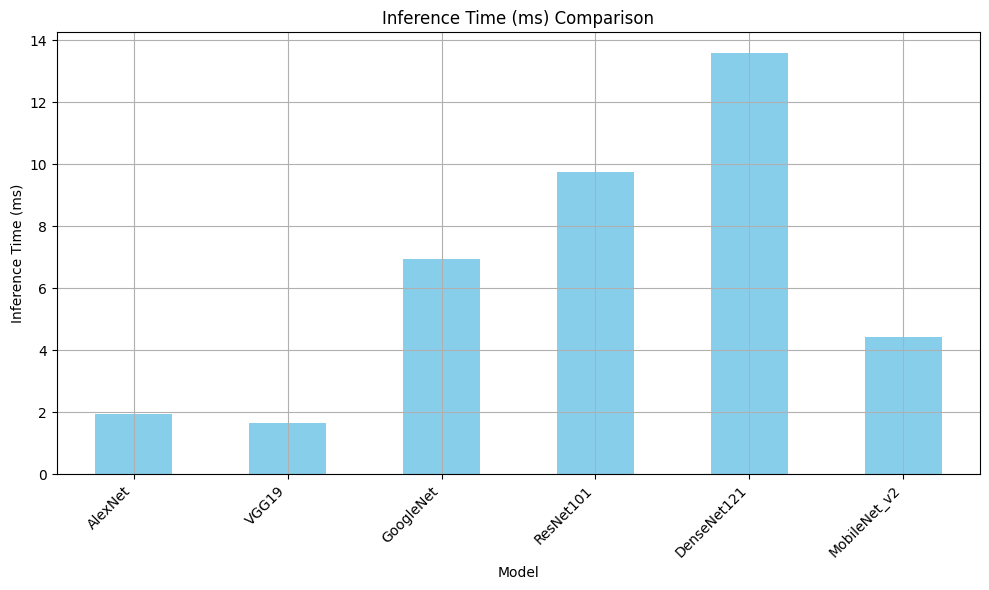

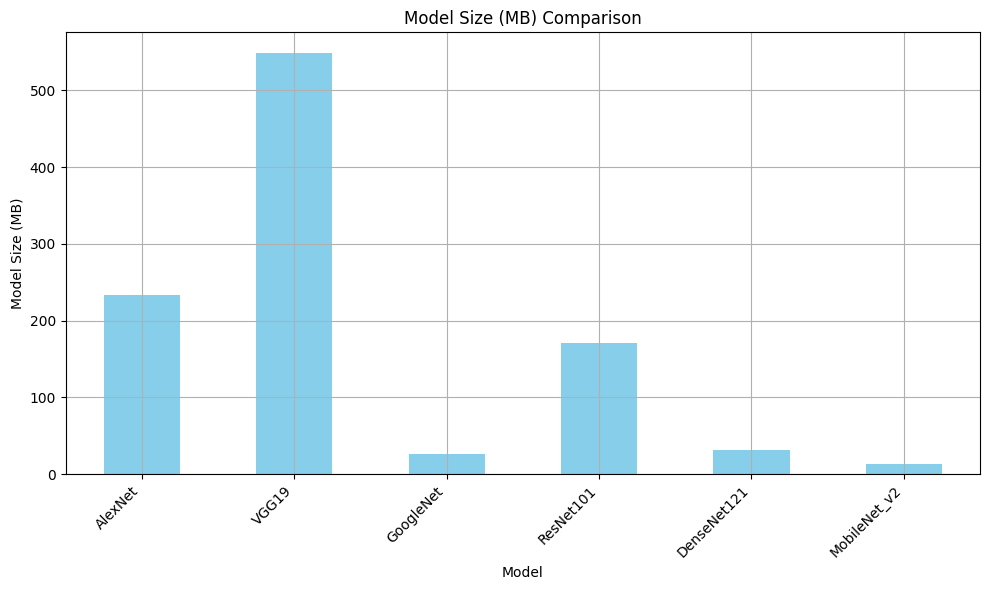

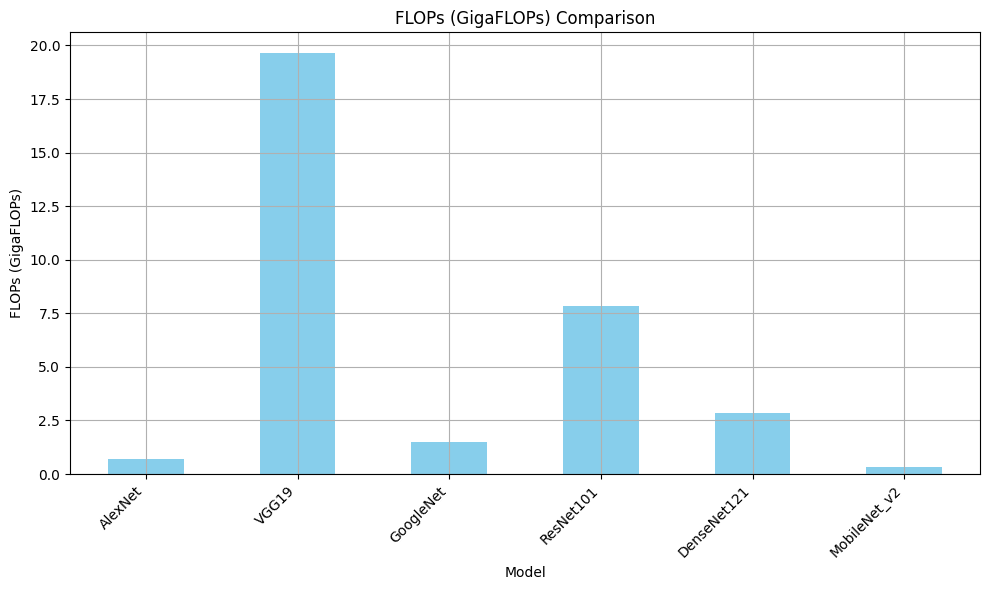

KeyError: '1% Accuracy '

<Figure size 1000x600 with 0 Axes>

In [23]:
results_df = pd.DataFrame(results).T

# Create individual bar plots for each metric
# Include accuracy metrics in the list
metrics = ['Inference Time (ms)', 'Model Size (MB)', 'FLOPs (GigaFLOPs)', '1% Accuracy ', '5% Accuracy']

for metric in metrics:
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    results_df[metric].plot(kind='bar', color='skyblue')

    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.grid(True)
    plt.tight_layout()

    plt.show()

# To do as home work


1. What is your inference on which model to be used if the dataset is closer to ImageNet dataset?
2. You can try to change the input image size to say 128x128 (e.g. set transforms.Resize(128)) and 256x256 and infer the results based on the bar plots? What is the reason we can feed in any sized image?
3. Change the batch size to 1 and observe the changes in inference time and accuracy. What is your inference?

## Answer:

### 1. 

Based on the data provided above in the chart, ResNet101 has the highest accuracy for both the 1% and 5% accuracy comparison. This puts it as a strong candidate for performance between the different models.
However, the MobileNet_v2 and VGG19 also have relatively high accuracy scores, 91.41% and 96.88% for 1% and 5% respectively for the MobileNet model and 89.58% and 96.88% for 1% and 5% for the VGG19 model. Thus, these 2 models can also be used as alternative choices.

Comparing based on inference time, VGG19 has the fastest inference time of 0.28ms, followed by MobileNet_v2 at 0.59ms. This makes them suitatble for real-time or low-latency applications.
That being said, even though the ResNet101 has a slightly longer inference time of 1.17ms, its high accuracy makes it a viable choice with a trade-off of the accuracy and inference time.

  Model Size
Smallest Model: MobileNet_v2 is the lightest in terms of model size (13.59 MB), making it ideal for resource-constrained environments.
Larger Models: VGG19 has a much larger model size (548 MB), which could be a problem for memory-limited environments.

 FLOPs (GigaFLOPs)
Low FLOPs: MobileNet_v2 has the lowest FLOPs (0.31 GigaFLOPs), which suggests it is more computationally efficient.
High FLOPs: VGG19 has the highest FLOPs (19.63 GigaFLOPs), which means it will require more computational resources and might not be the best choice for resource-constrained systems.
Inference on Model Selection:
If accuracy is your primary concern, ResNet101 would be the best choice due to its superior performance.
If you're looking for a balance between speed and accuracy, MobileNet_v2 could be a good option because it has relatively high accuracy with lower inference time and memory usage.
VGG19 could be chosen for situations where inference time is critical and model size is less of a concern, but it comes with trade-offs in terms of accuracy.

### 2.

 After changing the input size to 128, a key difference is that the inference time for multiple models has decreased, with the most significant being the timing for AlexNet dropping from 6ms to 0.034ms. SInce the image is smaller, lesser computation is needed to process the image, therefore a faster inference time.
  Additionally, the smaller input image also resulted in lesser number of operations that is required to process the image. As a result, there is a drop in FLOPs, with the number of FLOPs for ResNet101 dropping from 7.8 GigaFLOPs to 0.29 GigaFLOPS and that of MobileNet_v2 dropping from 0.31 to 0.12 GigaFLOPs.

  A key change to note is the drop in accuracy. Since the input image is now smaller, certain important features that was captured with larget input size is now lost. As a result, the model has a reduced ability to recognise these features that are necessary for a higher accuracy.

  Changing the input size to 256, it has led to a slight increase of inference time.

  The number of computation have also increased since the image is now larger. For example, the FLPOs for ResNet101 has increased from 0.29 GigaFLOPs to 0.42 GigaFLOPs while that for MobileNet_v2 has increased from 0.12 GigaFLOPs to 0.13 GigaFLOPs.

  A bigger input image means more features can be captured. This is shown in the increase in the accuracy for AlexNet, ResNet101 and MobileNet_v2. The increase is from 26.22% to 77.78% for 1% accuracy and 40.36% to 92.53% for 5% accuracy for AlexNet. The 1% accuracy for ResNet101 remained the same at 90.36% but the 5% accuracy increased from 88.98% to 100%.
  
  The different models can handle images of different sizes as each models have different spatial structure of conv layers. As a result, each model can work with different input image size to different extent.

### 3.

 When the batch size is changed to 1, the inference timing is noted to have increased significantly. The biggest change was for ResNet101, which increased from 0.421ms to 16.256ms. This change is expected since the model processes lesser images simultaneously, thus a higher inference time. Larger batch size would help to make computations more effective.

  The accuracy for all models increased, with the 1% accuracy for AlexNet increasing from 26.22% to 77% and ResNet101's 1% accuracy increasing from 74.05% to 90%.
